In [1]:
from importlib.resources import files, as_file
from nsbutils.plotting_pyvista import plot_surf
from neuromodes.eigen import EigenSolver, _mask_fem_matrices
from neuromodes.io import fetch_surf, fetch_map
import numpy as np
from scipy.sparse import csc_matrix
import matplotlib.pyplot as plt
from neuromodes.eigen import unparcellate
from neuromodes.stats import cdistw
from nsbutils.utils import unmask

In [2]:
# Load cortical surface mesh
surf, mask = fetch_surf()

# get mass and stiffness
solver = EigenSolver(surf, mask=mask).compute_lbo()
mass, stiffness = solver.mass, solver.stiffness

# load schaefer100
parcellation = np.loadtxt('C:/Users/ipop0003/neuromodes/docs/tutorials/tutorial_data/fsLR_32k_Schaefer900-lh.txt', dtype=int)[mask]

In [3]:
# Make a sparse parcellation matrix P (n_verts x n_parcs) such that P.T @ data = data_parc
mask_parc = parcellation != 0  # mask of non-medial wall vertices
parcellation_nnz = parcellation[mask_parc]  # non-zero parcellation labels
parcellation_nnz -= 1  # re-index to account for removed 0 parcel
n_verts = len(parcellation_nnz)  # number of non-medial wall vertices
print('Number of vertices:', n_verts)
n_parcs = len(np.unique(parcellation_nnz))
print('Number of parcels:', n_parcs)

P = csc_matrix((np.ones(n_verts), (np.arange(n_verts), parcellation_nnz)), shape=(n_verts, n_parcs))

Number of vertices: 29309
Number of parcels: 450


In [4]:
# get vertex areas from 30k mass matrix
mass_masked, _ = _mask_fem_matrices(mask_parc, mass=mass)
vert_areas = np.asarray(np.sum(mass_masked, axis=0))[0]
parc_areas = P.T @ vert_areas

# use area-weighted parcellation matrix to preserve total area
P_vp = P.multiply(vert_areas[:, np.newaxis] / parc_areas)

# use area-weighted parcellation matrix, assuming uniform vertex areas
P_p = P.multiply(1 / P.sum(axis=0))

In [35]:
# use to parcellate data
data = fetch_map(data='thickness')[mask][mask_parc] #emodes[:, -1][mask_parc]
data_unparc = unparcellate(P_p.T @ data, parcellation=parcellation)
data_unparcw = unparcellate(P_vp.T @ data, parcellation=parcellation)
corr = np.corrcoef(P_p.T @ data, P_vp.T @ data)
print('Correlation between parc(data) and parcw(data):', corr[0, 1])

ValueError: matmul: dimension mismatch with signature (n,k=29309),(k=29299,1?)->(n,1?)

In [36]:
# biharmonic interpolation
data_interp = unparcellate(P_vp.T @ data, parcellation=parcellation, mass=solver.mass, stiffness=solver.stiffness, interpolation='biharmonic')

C:\Users\ipop0003\neuromodes\neuromodes\eigen.py:823: UserWarning: Number of observations in data matches number of parcels excluding 0. Proceeding with removal of 0 parcel.
  warn('Number of observations in data matches number of parcels excluding 0. Proceeding with removal of 0 parcel.')


In [37]:
print('Correlation between original and parcellated data:', np.corrcoef(data, data_unparcw)[0, 1])
print('Correlation between original and interpolated data:', np.corrcoef(data, data_interp)[0, 1])

ValueError: all the input array dimensions except for the concatenation axis must match exactly, but along dimension 1, the array at index 0 has size 29299 and the array at index 1 has size 6

In [51]:
# re-parcellate interpolated data to check for consistency
data_interp_parc = P_vp.T @ data_interp
assert np.allclose(data_interp_parc, P_vp.T @ data, atol=1e-12), 'Re-parcellated interpolated data does not match original parcellated data'

In [34]:
all_data = np.stack([vert_areas, data, data_unparc, data_unparcw, data_interp], axis=1)

# plot all maps
all_data_unmasked = unmask(unmask(all_data, mask=mask_parc), mask=mask)
fig = plot_surf({'lh': surf}, data={'lh': all_data_unmasked}, rois={'lh': unmask(parcellation, mask=mask, val=0)}, views=['lateral', 'medial'], layout_indiv='col', layout_group='row', roi_outlines=True)
fig.show()

NameError: name 'data_unparc' is not defined

### Repeat across Schaefers

In [11]:
scales = range(10)
maps = ['fcgradient1', 'thickness', 'myelinmap', 'odi', 'ndi', 'saaxis']
data = np.stack([fetch_map(data=m)[mask] for m in maps], axis=1)
corrs = np.empty((len(scales), 2, len(maps)))
for i, s in enumerate(scales):
    parcellation = np.loadtxt(f'C:/Users/ipop0003/neuromodes/docs/tutorials/tutorial_data/fsLR_32k_Schaefer{s+1}00-lh.txt', dtype=int)[mask]
    
    # Make a sparse parcellation matrix P (n_verts x n_parcs) such that P.T @ data = data_parc
    mask_parc = parcellation != 0  # mask of non-medial wall vertices
    parcellation_nnz = parcellation[mask_parc]  # non-zero parcellation labels
    parcellation_nnz -= 1  # re-index to account for removed 0 parcel
    n_verts = len(parcellation_nnz)  # number of non-medial wall vertices
    n_parcs = len(np.unique(parcellation_nnz))

    P = csc_matrix((np.ones(n_verts), (np.arange(n_verts), parcellation_nnz)), shape=(n_verts, n_parcs))

    # get vertex areas from 30k mass matrix
    mass_masked, _ = _mask_fem_matrices(mask_parc, mass=mass)
    vert_areas = np.asarray(np.sum(mass_masked, axis=0))[0]
    parc_areas = P.T @ vert_areas

    # use area-weighted parcellation matrix to preserve total area
    P_vp = P.multiply(vert_areas[:, np.newaxis] / parc_areas)

    # unparcellate data via simple assignment
    data_unparcw = unparcellate(P_vp.T @ data[mask_parc], parcellation=parcellation, mass=solver.mass)

    # biharmonic interpolation
    data_interp = unparcellate(P_vp.T @ data[mask_parc], parcellation=parcellation, mass=solver.mass, stiffness=solver.stiffness, interpolation='biharmonic')

    # compute mass-weighted MSEs
    corrs[i, 0, :] = np.diag(cdistw(data_unparcw[:, None], data[mask_parc], mass=mass_masked, metric='correlation')[:, 0, :])
    corrs[i, 1, :] = np.diag(cdistw(data_interp[:, None], data[mask_parc], mass=mass_masked, metric='correlation')[:, 0, :])

    print('Done with scale', s+1)

C:\Users\ipop0003\neuromodes\neuromodes\eigen.py:823: UserWarning: Number of observations in data matches number of parcels excluding 0. Proceeding with removal of 0 parcel.
  warn('Number of observations in data matches number of parcels excluding 0. Proceeding with removal of 0 parcel.')


Done with scale 1
Done with scale 2
Done with scale 3
Done with scale 4
Done with scale 5
Done with scale 6
Done with scale 7
Done with scale 8
Done with scale 9
Done with scale 10


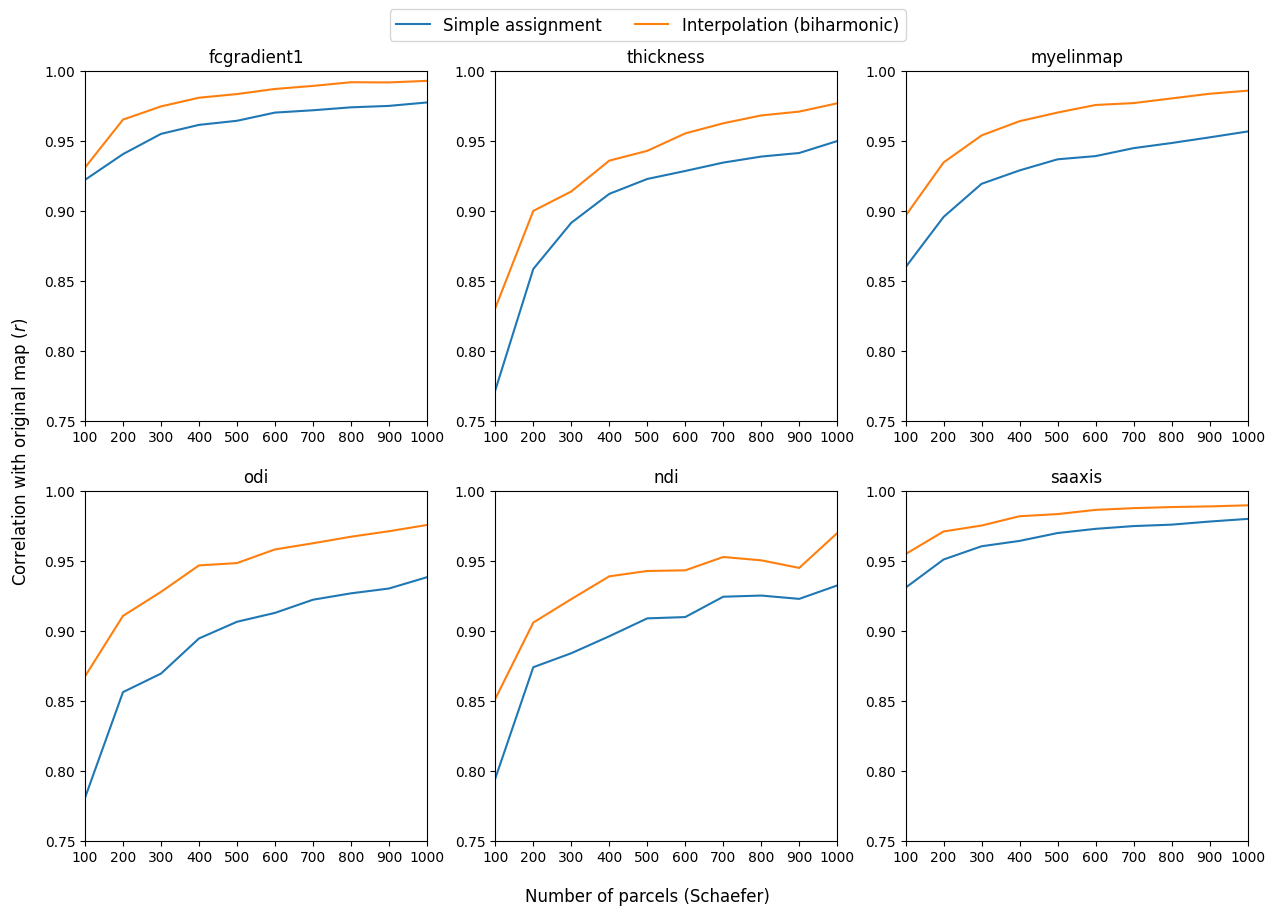

In [33]:
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
for j, m in enumerate(maps):
    plt.subplot(2, 3, j+1)
    plt.plot(scales, 1-corrs[:, 0, j])
    plt.plot(scales, 1-corrs[:, 1, j])
    plt.xticks(ticks=np.arange(len(scales)), labels=[f'{s+1}00' for s in scales])
    plt.ylim(0.75, 1)
    plt.xlim(0, len(scales)-1)
    plt.title(m)

fig.text(0.5, 0.05, 'Number of parcels (Schaefer)', ha='center', fontsize=12)
fig.text(0.075, 0.5, 'Correlation with original map ($r$)', va='center', rotation='vertical', fontsize=12)
fig.legend(['Simple assignment', 'Interpolation (biharmonic)'], bbox_to_anchor=(0.5, 0.95), loc='upper center', ncol=2, fontsize=12)

plt.show()